# Sentiment Analysis

## Project Objective

The objective of this project is to build a machine learning model that can classify text based on sentiment. The analysis focuses on preprocessing text data, converting text into numerical features using TF-IDF, training machine learning models, evaluating their performance, and identifying common classification errors.

## Tools and Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- NLTK
- Matplotlib
- Seaborn
- Jupyter Notebook

## Analysis Covered

1. Data Loading and Inspection
2. Sentiment Distribution
3. Text Preprocessing
4. TF-IDF Vectorization
5. Train-Test Split
6. Naive Bayes Classification
7. Logistic Regression Classification
8. Model Evaluation
9. Confusion Matrix
10. Sentiment Visualization
11. WordCloud
12. Error Analysis
13. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import nltk

In [2]:
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    "../dataset/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=columns
)

In [4]:
df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.shape

(1600000, 6)

In [6]:
df.info

<bound method DataFrame.info of          target         ids                          date      flag  \
0             0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1             0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2             0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3             0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4             0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
...         ...         ...                           ...       ...   
1599995       4  2193601966  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599996       4  2193601969  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599997       4  2193601991  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599998       4  2193602064  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599999       4  2193602129  Tue Jun 16 08:40:50 PDT 2009  NO_QUERY   

                    user                                               text  
0        _TheSpecialOne_  @switchfoot

In [7]:
df.isnull().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Understanding Sentiment Labels

The dataset uses the `target` column as the sentiment label.

- 0 represents negative sentiment.
- 4 represents positive sentiment.

The sentiment labels will be converted into a simpler binary representation:

- 0 → Negative
- 1 → Positive

In [9]:
df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [10]:
df = df[df['target'].isin([0, 4])].copy()

df['sentiment'] = df['target'].map({
    0: 0,
    4: 1
})

In [11]:
df['sentiment'].value_counts()

sentiment
0    800000
1    800000
Name: count, dtype: int64

## Sentiment Distribution

The distribution of positive and negative tweets was examined to understand the class balance of the dataset.

In [12]:
sentiment_counts = df['sentiment'].value_counts().sort_index()

sentiment_counts.index = ['Negative', 'Positive']

sentiment_counts

Negative    800000
Positive    800000
Name: count, dtype: int64

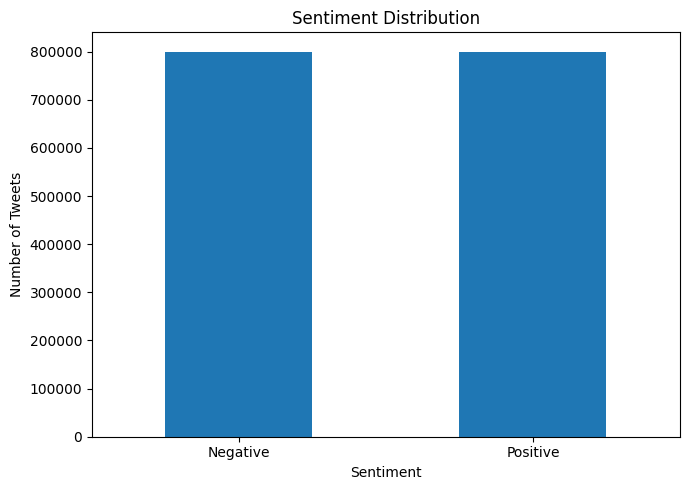

In [13]:
plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The dataset contains both negative and positive tweets. The distribution is approximately balanced between the two sentiment classes, which is useful for training a binary sentiment classification model.

In [14]:
df = df[['text', 'sentiment']].copy()

df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [15]:
df.shape

(1600000, 2)

In [16]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

## Text Preprocessing

Raw social-media text can contain URLs, mentions, hashtags, punctuation, numbers, and unnecessary whitespace.

The following preprocessing steps are applied:

- Convert text to lowercase
- Remove URLs
- Remove user mentions
- Remove punctuation
- Remove numbers
- Remove English stopwords
- Remove extra whitespace

In [18]:
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Join words and remove extra spaces
    text = ' '.join(words)
    
    return text

In [19]:
sample_text = df['text'].iloc[0]

print("Original Text:")
print(sample_text)

print("\nCleaned Text:")
print(clean_text(sample_text))

Original Text:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned Text:
thats bummer shoulda got david carr third day


### Applying Text Preprocessing

The cleaning function was applied to the complete text column to create a new cleaned-text column. The original text is retained so that the raw data is not lost.

In [20]:
df['clean_text'] = df['text'].apply(clean_text)

In [21]:
df[['text', 'clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


In [22]:
df = df[df['clean_text'].str.strip() != ''].copy()

print("Dataset shape after removing empty text:", df.shape)

Dataset shape after removing empty text: (1592791, 3)


## Dataset Sampling

The original dataset contains a large number of tweets. To make model training computationally manageable in a Jupyter Notebook environment, a representative sample was selected.

A fixed random state is used so that the same sample can be reproduced.

In [23]:
sample_size = 100000

if len(df) > sample_size:
    df_sample = df.sample(n=sample_size, random_state=42)
else:
    df_sample = df.copy()

print("Sample size:", len(df_sample))

Sample size: 100000


In [24]:
df_sample['sentiment'].value_counts()

sentiment
1    50254
0    49746
Name: count, dtype: int64

## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

The training set is used to learn patterns from the text, while the testing set is used to evaluate how well the trained models perform on unseen data.

In [25]:
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80000
Testing samples: 20000


## TF-IDF Vectorization

Machine learning models cannot directly understand raw text. Therefore, the cleaned text is converted into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF gives higher importance to words that are frequent in a particular document but less common across the entire collection of documents.

This allows the machine learning models to use important textual patterns for sentiment classification.

In [26]:
tfidf = TfidfVectorizer(
    max_features=20000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80000, 19226)
Testing TF-IDF shape: (20000, 19226)


In [27]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 518486 stored elements and shape (80000, 19226)>

In [28]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 126176 stored elements and shape (20000, 19226)>

## Model 1 — Multinomial Naive Bayes

Multinomial Naive Bayes is a commonly used classification algorithm for text data. It works well with numerical representations such as TF-IDF features and is suitable for binary text classification.

In [29]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## Model 2 — Logistic Regression

Logistic Regression is a supervised classification algorithm that can be used to classify text into positive and negative sentiment classes.

A second model is trained so that its performance can be compared with Naive Bayes.

In [30]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Model Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide different perspectives on classification performance.

In [31]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model('Naive Bayes', y_test, nb_predictions),
    evaluate_model('Logistic Regression', y_test, lr_predictions)
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.75270,0.758011,0.746095,0.752006
1,Logistic Regression,0.76345,0.754740,0.784101,0.769141


## Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model for each sentiment class.

It helps identify whether the model is confusing negative tweets with positive tweets or vice versa.

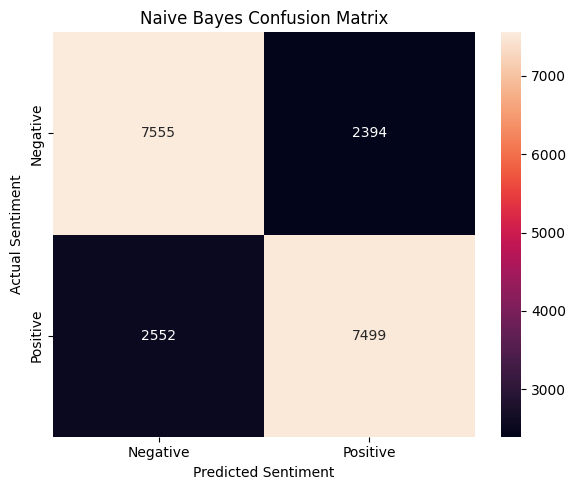

In [32]:
cm_nb = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.tight_layout()
plt.show()


## Detailed Classification Reports

Precision, recall, and F1-score were calculated separately for the negative and positive sentiment classes.

These metrics provide a more detailed evaluation than accuracy alone.

In [34]:
print("Naive Bayes Classification Report")
print(classification_report(
    y_test,
    nb_predictions,
    target_names=['Negative', 'Positive']
))

Naive Bayes Classification Report
              precision    recall  f1-score   support

    Negative       0.75      0.76      0.75      9949
    Positive       0.76      0.75      0.75     10051

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



In [35]:
print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    lr_predictions,
    target_names=['Negative', 'Positive']
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    Negative       0.77      0.74      0.76      9949
    Positive       0.75      0.78      0.77     10051

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



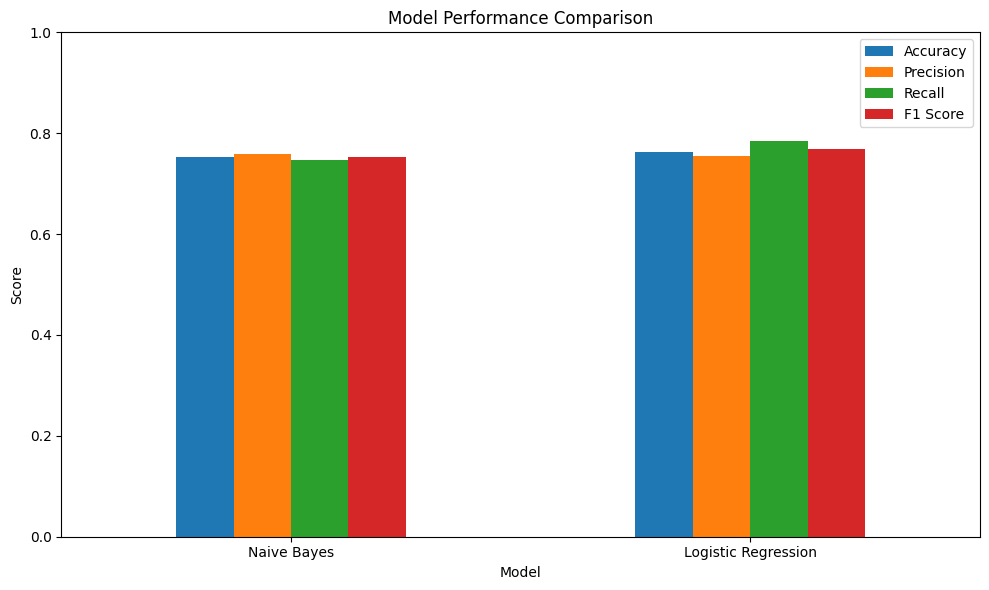

In [36]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(kind='bar', figsize=(10, 6))

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Model Comparison

The performance of Multinomial Naive Bayes and Logistic Regression was compared using accuracy, precision, recall, and F1-score.

The model with stronger overall evaluation metrics can be considered more suitable for this sentiment classification task. The final choice should be based on the evaluation results rather than accuracy alone.

In [37]:
!pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from wordcloud import WordCloud

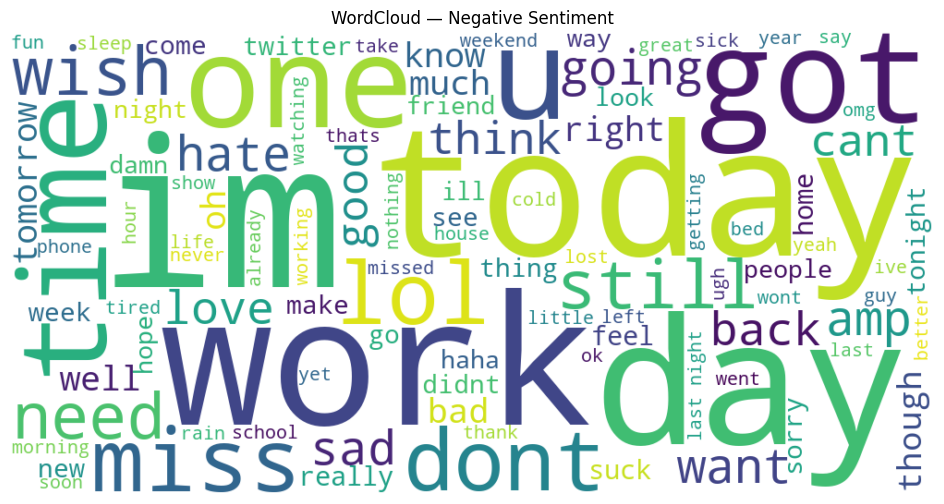

In [39]:
negative_text = ' '.join(
    df_sample[df_sample['sentiment'] == 0]['clean_text']
)

negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Negative Sentiment')
plt.show()

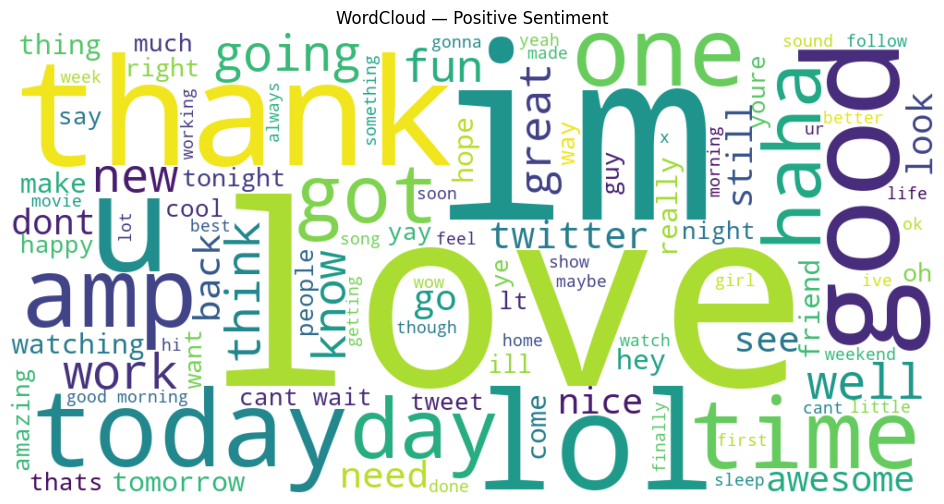

In [40]:
positive_text = ' '.join(
    df_sample[df_sample['sentiment'] == 1]['clean_text']
)

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Positive Sentiment')
plt.show()

## Error Analysis

Error analysis was performed to understand examples where the model predicted the wrong sentiment.

Examining misclassified tweets can reveal challenges such as:

- Sarcasm
- Negation
- Informal language
- Slang
- Spelling variations
- Ambiguous expressions
- Lack of context

In [41]:
error_analysis = pd.DataFrame({
    'Text': X_test.values,
    'Actual': y_test.values,
    'Predicted': lr_predictions
})

misclassified = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
].copy()

misclassified['Actual'] = misclassified['Actual'].map({
    0: 'Negative',
    1: 'Positive'
})

misclassified['Predicted'] = misclassified['Predicted'].map({
    0: 'Negative',
    1: 'Positive'
})

misclassified.head(5)

,Text,Actual,Predicted
5,long time searching im already feeling vibe th...,Negative,Positive
12,good morning results today however get another...,Negative,Positive
15,ohmygod youre insane house greatest show face ...,Negative,Positive
16,ofcourse wanna take pic amp stop state line,Positive,Negative
18,way beach way cold fuck,Positive,Negative


In [42]:
misclassified.head(5)

,Text,Actual,Predicted
5,long time searching im already feeling vibe th...,Negative,Positive
12,good morning results today however get another...,Negative,Positive
15,ohmygod youre insane house greatest show face ...,Negative,Positive
16,ofcourse wanna take pic amp stop state line,Positive,Negative
18,way beach way cold fuck,Positive,Negative


### Misclassification Observations

The misclassified examples demonstrate that sentiment classification can be difficult when tweets contain informal language, sarcasm, negation, ambiguous wording, or insufficient context.

These cases show that even when a model performs well overall, individual predictions can still be incorrect.

## Key Insights

1. Text preprocessing helped convert raw tweets into a cleaner format suitable for machine learning.

2. TF-IDF transformed textual information into numerical features that could be processed by classification algorithms.

3. Multinomial Naive Bayes and Logistic Regression were trained and evaluated on the same test dataset.

4. Accuracy, precision, recall, and F1-score were used to compare model performance.

5. The confusion matrices provided a visual representation of correct and incorrect classifications.

6. WordCloud visualizations helped identify frequently occurring words within positive and negative tweets.

7. Error analysis showed that informal language, sarcasm, negation, and lack of context can make sentiment classification challenging.

## Conclusion

The sentiment analysis project successfully demonstrated an end-to-end Natural Language Processing and machine learning workflow.

The project included text preprocessing, TF-IDF feature extraction, train-test splitting, Multinomial Naive Bayes classification, Logistic Regression classification, model evaluation, confusion matrix analysis, sentiment visualization, WordCloud generation, and error analysis.

The comparison of the two models provides an understanding of how different classification algorithms perform on text data.

The project also demonstrates that sentiment analysis can be useful for understanding public opinion, customer feedback, and social-media content. However, individual tweets can be difficult to classify correctly because of sarcasm, informal language, ambiguity, and lack of context.

In [43]:
results.to_csv(
    "../output/model_performance.csv",
    index=False
)

print("Model performance saved successfully.")

Model performance saved successfully.


In [44]:
misclassified.head(5).to_csv(
    "../output/misclassified_examples.csv",
    index=False
)

print("Misclassified examples saved successfully.")

Misclassified examples saved successfully.


In [45]:
df_sample.to_csv(
    "../output/processed_sentiment_sample.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
